Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [22]:
# cell for imports. All imports must go here.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [3]:
titanic_df = pd.read_csv("train.csv")

print("general info")
titanic_df.info()

general info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print("first 5 strings")
print(titanic_df.head())

first 5 strings
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

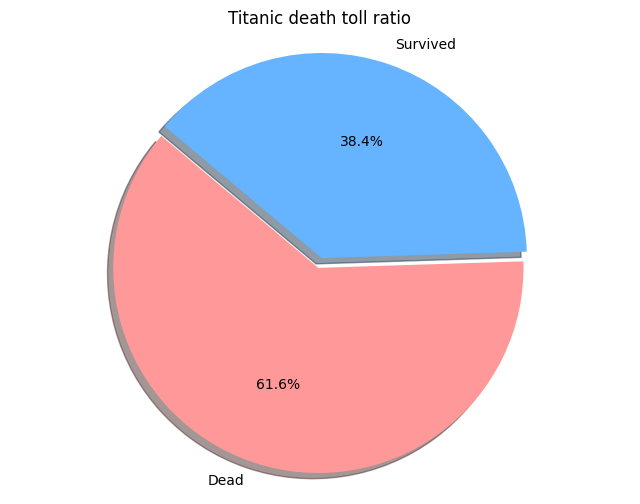

In [12]:
survival_counts = titanic_df["Survived"].value_counts(dropna=True)
labels = ["Dead", "Survived"]
sizes = [survival_counts[0], survival_counts[1]]
colors = ["#ff9999","#66b3ff"]

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=(0.05, 0), labels=labels, colors=colors, autopct="%1.1f%%", shadow=True, startangle=140)
plt.title("Titanic death toll ratio")
plt.axis("equal")
plt.show()

Кругова діаграма чітко демонструє, що більшість пасажирів загинули. Сектор, що відповідає загиблим займає значно більше половини площі кола. Ця візуалізація слугує наочним підтвердженням масштабів катастрофи Титаніка.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


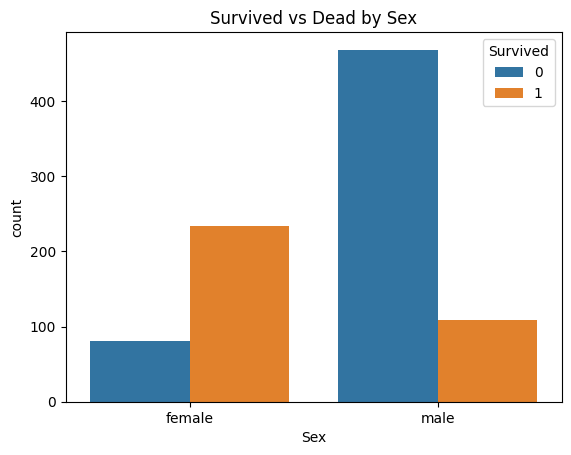

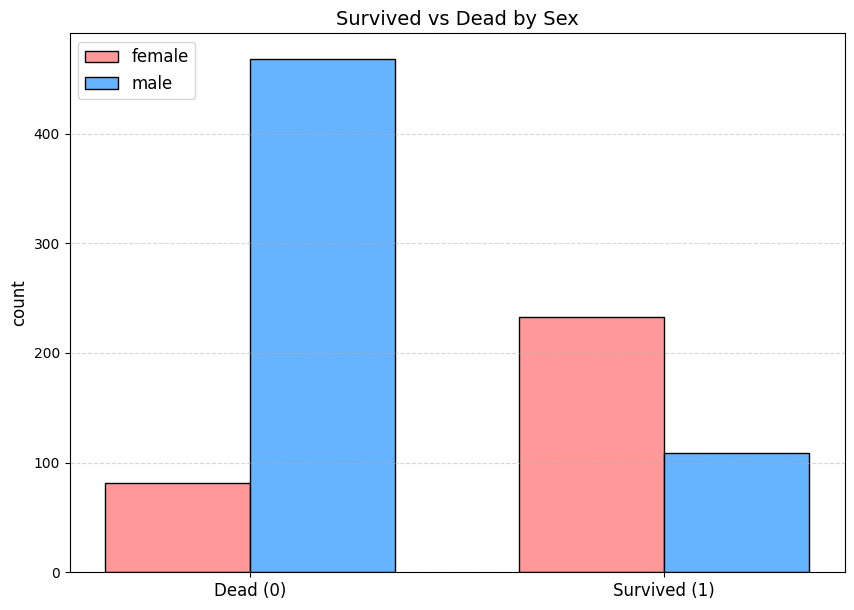

In [13]:
grouped_data = titanic_df.groupby(["Sex", "Survived"], as_index=False).size()
grouped_data.columns = ["Sex", "Survived", "Passenger Count"]

pivot_df = grouped_data.pivot(index="Survived", columns="Sex", values="Passenger Count")

x_indices = np.arange(len(pivot_df.index))
bar_width = 0.35

plt.figure(figsize=(10, 7))

rects1 = plt.bar(x_indices - bar_width/2, pivot_df["female"], bar_width, label="female", color="#ff9999", edgecolor="black")
rects2 = plt.bar(x_indices + bar_width/2, pivot_df["male"], bar_width, label="male", color="#66b3ff", edgecolor="black")

plt.title("Survived vs Dead by Sex", fontsize=14)
plt.ylabel("count", fontsize=12)
plt.xticks(x_indices, ["Dead (0)", "Survived (1)"], fontsize=12)
plt.legend(fontsize=12, loc="upper left")
plt.grid(axis="y", linestyle='--', alpha=0.5)

plt.show()

Графік однозначно демонструє, що стать була критичним фактором виживання. Шанси вижити у жінки були в рази вищими, ніж у чоловіка.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

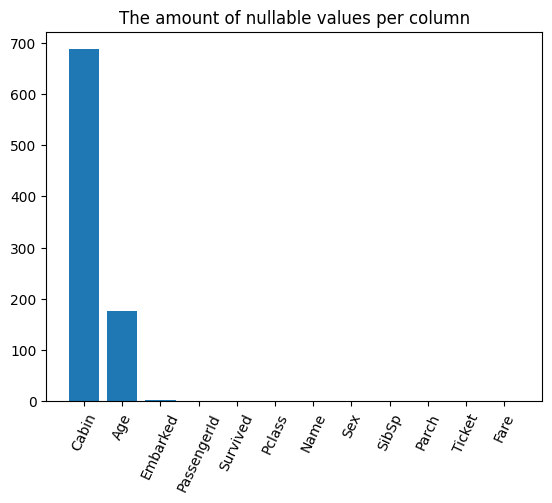

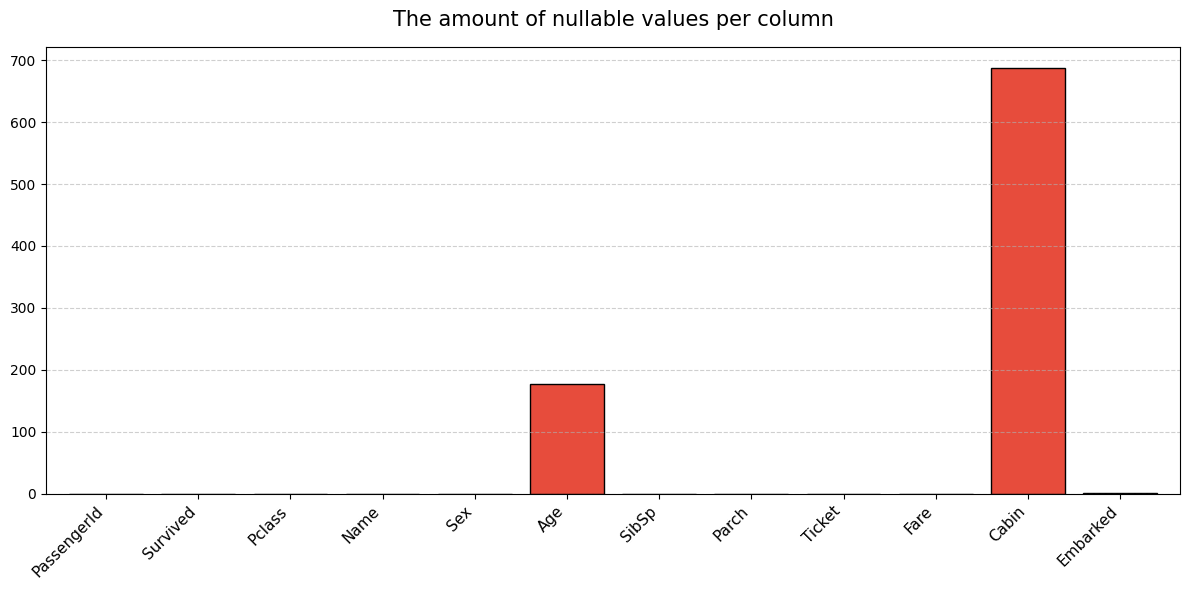

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

missing_values = titanic_df.isnull().sum()

plt.figure(figsize=(12, 6))

ax = missing_values.plot(kind="bar", color="#e74c3c", edgecolor="black", width=0.8)

plt.title("The amount of nullable values per column", fontsize=15, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.grid(axis="y", linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Найбільша кількість пропусків у колоці каюта, можливо для пасажирів третього класу не передбачався номер каюти. Також багато нульових даних в колонці вік, хоча це одна з найважливіших колонок, оскільки рятували людей за правилом "перші жінки і діти".

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

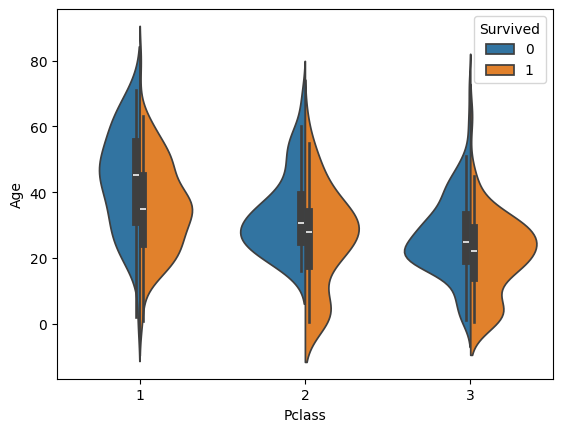

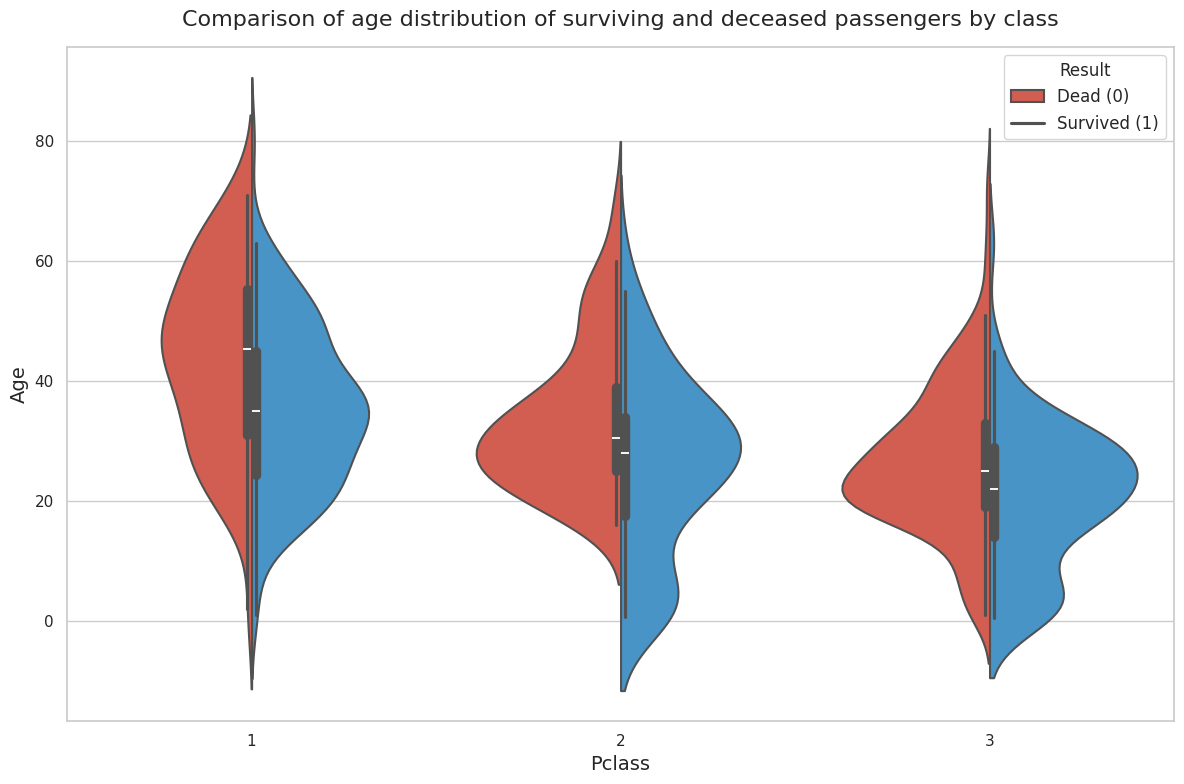

In [32]:
df_clean = titanic_df.dropna(subset=['Age'])

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.violinplot(data=df_clean, x="Pclass", y="Age", hue="Survived", split=True,palette={0: "#e74c3c", 1: "#3498db"}, linewidth=1.5)

plt.title("Comparison of age distribution of surviving and deceased passengers by class", fontsize=16, pad=15)
plt.xlabel("Pclass", fontsize=14)
plt.ylabel("Age", fontsize=14)

plt.legend(title="Result", fontsize=12, loc="upper right", labels=["Dead (0)", "Survived (1)"])

plt.tight_layout()
plt.show()

Ця візуалізація є математичним підтвердженням історичних фактів. Вона доводить, що правило "спочатку жінки та діти" дійсно працювало, але з жорсткою поправкою на соціальний статус. Дитина з другого класу мала гарантований шанс на життя, тоді як молодий чоловік або навіть дитина з третього класу були приречені з найбільшою ймовірністю.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


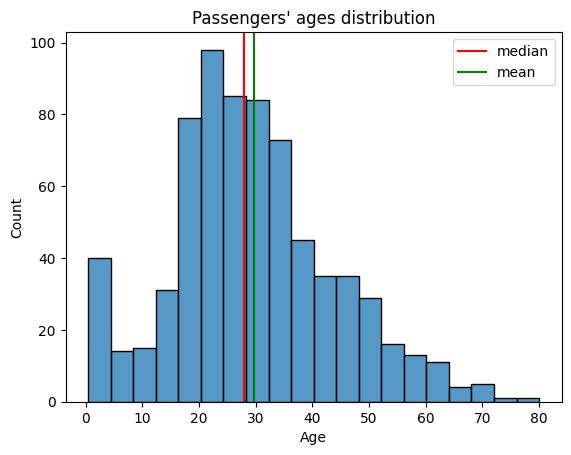

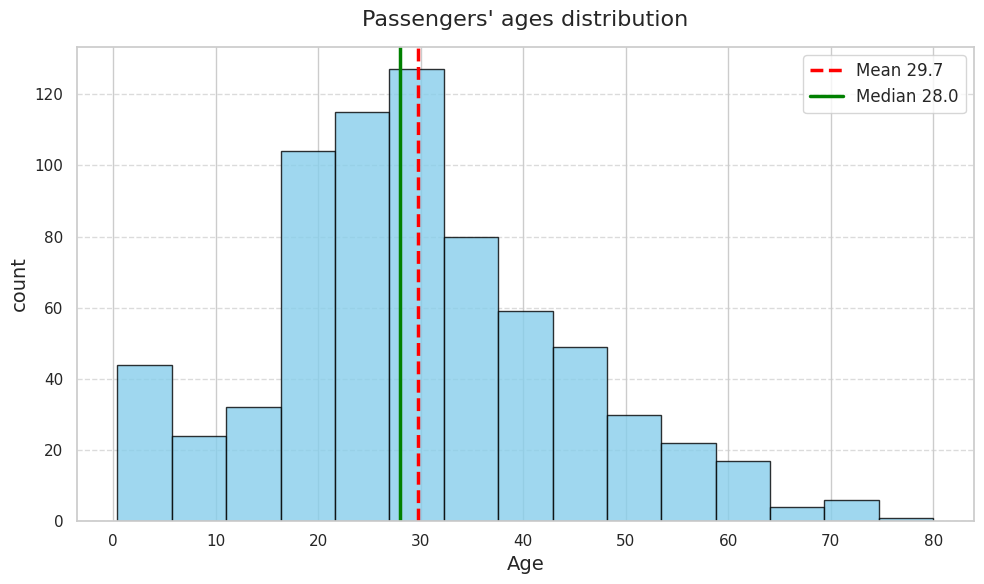

In [34]:
age_data = titanic_df['Age'].dropna()

mean_age = age_data.mean()
median_age = age_data.median()

plt.figure(figsize=(10, 6))
plt.hist(age_data, bins=15, color="skyblue", edgecolor="black", alpha=0.8)
plt.axvline(mean_age, color="red", linestyle='--', linewidth=2.5, label=f"Mean {mean_age:.1f}")
plt.axvline(median_age, color="green", linestyle='-', linewidth=2.5, label=f"Median {median_age:.1f}")

plt.title("Passengers' ages distribution", fontsize=16, pad=15)
plt.xlabel("Age", fontsize=14)
plt.ylabel("count", fontsize=14)
plt.grid(axis="y", linestyle='--', alpha=0.7)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

Для опису "типового" віку пасажира Титаніка статистично правильніше використовувати саме медіану (28 років), оскільки середнє значення трохи спотворене літніми людьми.

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Чи впливає наявність сім'ї на борту на шанси пасажира вижити під час катастрофи? Як ця характеристика розподілена за класами обслуговування?

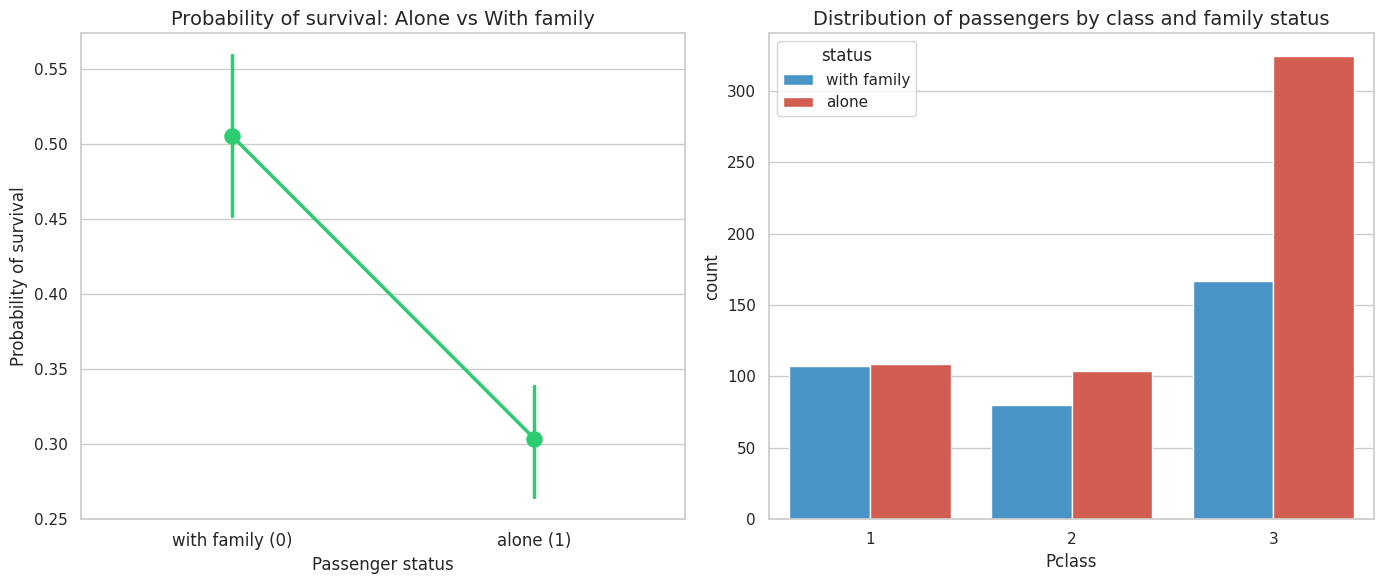

In [39]:
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1

titanic_df["IsAlone"] = 1
titanic_df.loc[titanic_df["FamilySize"] > 1, "IsAlone"] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.pointplot(x="IsAlone", y="Survived", data=titanic_df, ax=axes[0], color="#2ecc71", markersize=10, linewidth=2.5)
axes[0].set_title("Probability of survival: Alone vs With family", fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["with family (0)", "alone (1)"], fontsize=12)
axes[0].set_ylabel("Probability of survival", fontsize=12)
axes[0].set_xlabel("Passenger status", fontsize=12)

sns.countplot(x="Pclass", hue="IsAlone", data=titanic_df, ax=axes[1], palette=["#3498db", "#e74c3c"])
axes[1].set_title("Distribution of passengers by class and family status", fontsize=14)
axes[1].set_xlabel("Pclass", fontsize=12)
axes[1].set_ylabel("count", fontsize=12)
axes[1].legend(title="status", labels=["with family", "alone"], loc="upper left")

plt.tight_layout()
plt.show()

Пасажири, які подорожували з сім'єю, мали значно вищі шанси на порятунок, ніж ті, хто подорожував сам. Сім'ї, ймовірно, краще кооперувалися, швидше дізнавалися про небезпеку одне від одного і допомагали одне одному дістатися шлюпок. Більшість одиноких пасажирів були трудовими мігрантами (переважно молодими чоловіками) з найдешевшого класу. Низький рівень виживання "одинаків" зумовлений перетином двох факторів: по-перше, відсутністю підтримки близьких під час паніки, а по-друге, їхнім соціальним статусом (більшість із них знаходилися на нижніх палубах 3-го класу, звідки було найважче вибратися).

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

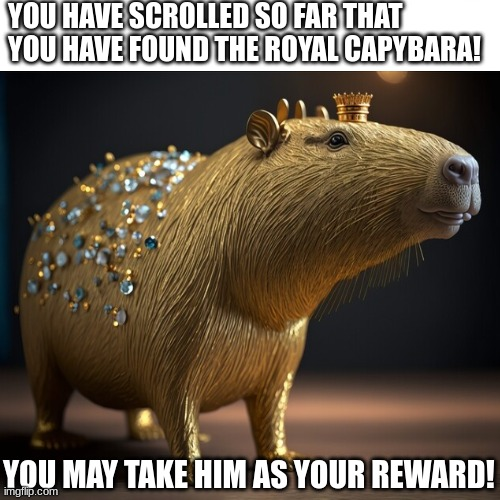